# **=== Mount Google Drive ===**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# ***=== Data Loading ===***

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Hogwarts_House_Sorting/harry_potter_1000_students.csv")

In [ ]:
df.head()

,Blood Status,Bravery,Intelligence,Loyalty,Ambition,Dark Arts Knowledge,Quidditch Skills,Dueling Skills,Creativity,House
0,Half-blood,9,4,7,5,0,8,8,7,Gryffindor
1,Muggle-born,6,8,5,7,5,6,4,9,Ravenclaw
2,Pure-blood,1,4,7,7,1,4,4,6,Hufflepuff
3,Pure-blood,9,1,3,4,1,9,10,1,Gryffindor
4,Muggle-born,5,9,7,3,3,6,7,9,Ravenclaw


# ***=== Data Analysis ===***

In [ ]:
df.shape

(1000, 10)

In [ ]:
df.info

<bound method DataFrame.info of     Blood Status  Bravery  Intelligence  Loyalty  Ambition  \
0     Half-blood        9             4        7         5   
1    Muggle-born        6             8        5         7   
2     Pure-blood        1             4        7         7   
3     Pure-blood        9             1        3         4   
4    Muggle-born        5             9        7         3   
..           ...      ...           ...      ...       ...   
995   Half-blood        7            10        3         7   
996   Pure-blood        7             3        2         7   
997   Half-blood        5            10        5         3   
998   Half-blood        5             6       10         4   
999   Half-blood        7             1       10         5   

     Dark Arts Knowledge  Quidditch Skills  Dueling Skills  Creativity  \
0                      0                 8               8           7   
1                      5                 6               4           9   
2                      1                 4               4           6   
3                      1                 9              10           1   
4                      3                 6               7           9   
..                   ...               ...             ...         ...   
995                    1                 1               3           8   
996                    8                 6               7           7   
997                    3                 5               7          10   
998                    4                 6               2           4   
999                    3                 0               3           3   

          House  
0    Gryffindor  
1     Ravenclaw  
2    Hufflepuff  
3    Gryffindor  
4     Ravenclaw  
..          ...  
995   Ravenclaw  
996   Slytherin  
997   Ravenclaw  
998  Hufflepuff  
999  Hufflepuff  

[1000 rows x 10 columns]>

In [ ]:
df.describe

<bound method NDFrame.describe of     Blood Status  Bravery  Intelligence  Loyalty  Ambition  \
0     Half-blood        9             4        7         5   
1    Muggle-born        6             8        5         7   
2     Pure-blood        1             4        7         7   
3     Pure-blood        9             1        3         4   
4    Muggle-born        5             9        7         3   
..           ...      ...           ...      ...       ...   
995   Half-blood        7            10        3         7   
996   Pure-blood        7             3        2         7   
997   Half-blood        5            10        5         3   
998   Half-blood        5             6       10         4   
999   Half-blood        7             1       10         5   

     Dark Arts Knowledge  Quidditch Skills  Dueling Skills  Creativity  \
0                      0                 8               8           7   
1                      5                 6               4           9   
2                      1                 4               4           6   
3                      1                 9              10           1   
4                      3                 6               7           9   
..                   ...               ...             ...         ...   
995                    1                 1               3           8   
996                    8                 6               7           7   
997                    3                 5               7          10   
998                    4                 6               2           4   
999                    3                 0               3           3   

          House  
0    Gryffindor  
1     Ravenclaw  
2    Hufflepuff  
3    Gryffindor  
4     Ravenclaw  
..          ...  
995   Ravenclaw  
996   Slytherin  
997   Ravenclaw  
998  Hufflepuff  
999  Hufflepuff  

[1000 rows x 10 columns]>

In [ ]:
df.isnull().sum()

,0
Blood Status,0
Bravery,0
Intelligence,0
Loyalty,0
Ambition,0
Dark Arts Knowledge,0
Quidditch Skills,0
Dueling Skills,0
Creativity,0
House,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns

Index(['Blood Status', 'Bravery', 'Intelligence', 'Loyalty', 'Ambition',
       'Dark Arts Knowledge', 'Quidditch Skills', 'Dueling Skills',
       'Creativity', 'House'],
      dtype='object')

In [ ]:
df['House'].value_counts()

,count
House,
Slytherin,265
Ravenclaw,258
Hufflepuff,251
Gryffindor,226


# ***=== Data Preprocessing And Preprocessing ===***

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
house_encoder = LabelEncoder()
blood_encoder = LabelEncoder()

In [ ]:
df['House'] = house_encoder.fit_transform(df['House'])
df['Blood Status'] = blood_encoder.fit_transform(df['Blood Status'])

In [ ]:
df.head()

,Blood Status,Bravery,Intelligence,Loyalty,Ambition,Dark Arts Knowledge,Quidditch Skills,Dueling Skills,Creativity,House
0,0,9,4,7,5,0,8,8,7,0
1,1,6,8,5,7,5,6,4,9,2
2,2,1,4,7,7,1,4,4,6,1
3,2,9,1,3,4,1,9,10,1,0
4,1,5,9,7,3,3,6,7,9,2


In [ ]:
X = df.drop("House", axis=1)
y = df["House"]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.25,
    random_state=7,
    stratify=y
)

# ***=== Training ===***

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=16,
    callbacks=[early_stop]
)

Epoch 1/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8667 - loss: 0.4949 - val_accuracy: 0.9920 - val_loss: 0.6112
Epoch 2/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9720 - loss: 0.0921 - val_accuracy: 1.0000 - val_loss: 0.2887
Epoch 3/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9853 - loss: 0.0555 - val_accuracy: 0.9960 - val_loss: 0.1441
Epoch 4/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9880 - loss: 0.0437 - val_accuracy: 0.9880 - val_loss: 0.0871
Epoch 5/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9867 - loss: 0.0356 - val_accuracy: 0.9960 - val_loss: 0.0459
Epoch 6/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9907 - loss: 0.0405 - val_accuracy: 0.9960 - val_loss: 0.0341
Epoch 7/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9947 - loss: 0.0275 - val_accuracy: 0.9960 - val_loss: 0.0290
Epoch 8/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9893 - loss: 0.0374 - val_accuracy: 0.9920 - val_los

# ***=== Model Implementation ===***

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(9,)),
    BatchNormalization(),

    Dense(64, activation='relu'),

    Dense(16, activation='relu'),

    Dense(4, activation='softmax')
])

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,156 (43.58 KB)

 Trainable params: 10,900 (42.58 KB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# ***=== Evaluation Metrics ===***

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns

In [ ]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [ ]:
index_to_label = {
    0:"Gryffindor",
    1:"Hufflepuff",
    2:"Ravenclaw",
    3:"Slytherin"
}

In [ ]:
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=list(index_to_label.values())))

Classification Report:

              precision    recall  f1-score   support

  Gryffindor       1.00      1.00      1.00        43
  Hufflepuff       1.00      0.98      0.99        47
   Ravenclaw       0.98      1.00      0.99        61
   Slytherin       1.00      1.00      1.00        49

    accuracy                           0.99       200
   macro avg       1.00      0.99      1.00       200
weighted avg       1.00      0.99      0.99       200



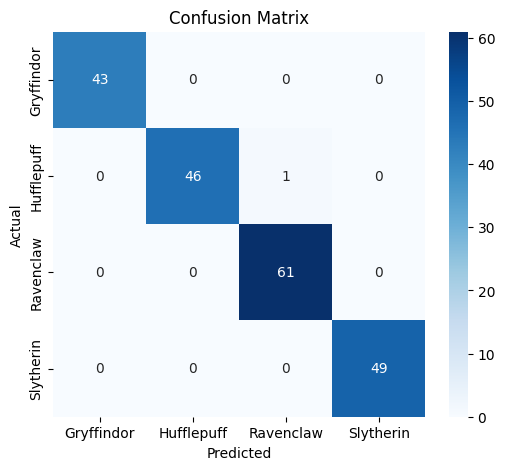

In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(index_to_label.values()),
            yticklabels=list(index_to_label.values()))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"✅ Accuracy: {acc:.4f}")
print(f"✅ Precision: {prec:.4f}")
print(f"✅ Recall: {rec:.4f}")
print(f"✅ F1-score: {f1:.4f}")

✅ Accuracy: 0.9950
✅ Precision: 0.9951
✅ Recall: 0.9950
✅ F1-score: 0.9950


# ***=== Graphs===***

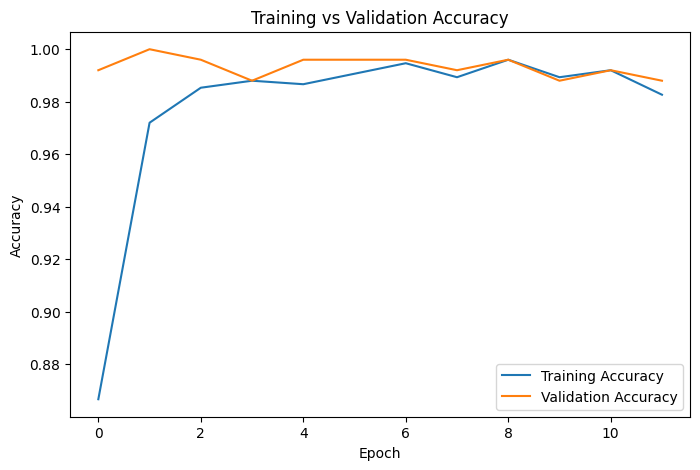

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Training Accuracy",
    "Validation Accuracy"
])

plt.show()

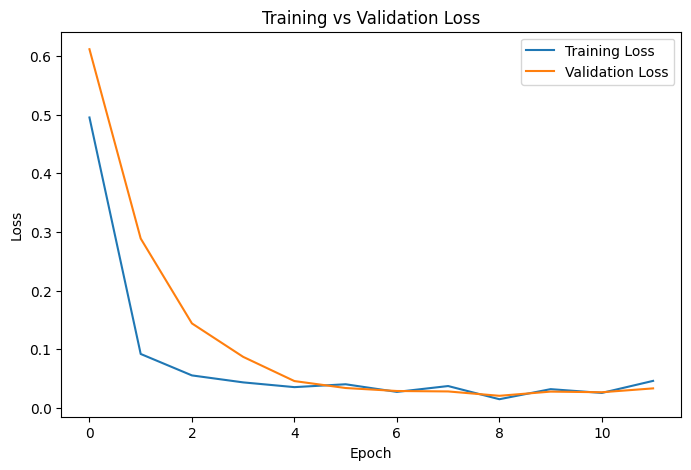

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Training Loss",
    "Validation Loss"
])

plt.show()

# ***=== Final Prediction ===***

In [ ]:
student = np.array([[1,8,9,6,5,4,7,8,9]])

prediction = model.predict(student)

predicted_class = np.argmax(prediction)

house_names = {
    0: "Gryffindor",
    1: "Hufflepuff",
    2: "Ravenclaw",
    3: "Slytherin"
}

print("Predicted Hogwarts House:")
print(house_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
Predicted Hogwarts House:
Hufflepuff
